In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/CamVid'

In [4]:
!ls /content/drive/MyDrive/Colab\ Notebooks/CamVid/train/images | head
!ls /content/drive/MyDrive/Colab\ Notebooks/CamVid/train/labels | head

0001TP_009210.png
0001TP_009240.png
0001TP_009390.png
0001TP_009420.png
0001TP_009450.png
0001TP_009480.png
0001TP_009510.png
0001TP_009540.png
0001TP_009690.png
0001TP_009720.png
0001TP_009210_L.png
0001TP_009240_L.png
0001TP_009390_L.png
0001TP_009420_L.png
0001TP_009450_L.png
0001TP_009480_L.png
0001TP_009510_L.png
0001TP_009540_L.png
0001TP_009690_L.png
0001TP_009720_L.png


In [5]:
CAMVID_CLASSES = [
    "Sky", "Building", "Pole", "Road", "Pavement",
    "Tree", "SignSymbol", "Fence", "Car",
    "Pedestrian", "Bicyclist"
]


In [6]:
# Standard CamVid 12-class colors (RGB)
class_colors = [
    [128, 128, 128], [128, 0, 0], [192, 192, 128], [128, 64, 128],
    [0, 0, 192], [128, 128, 0], [192, 128, 128], [64, 64, 128],
    [64, 0, 128], [64, 64, 0], [0, 128, 192], [0, 0, 0]
]

In [7]:
def rgb_to_mask(rgb_mask):
    """Efficiently converts RGB mask to class IDs using broadcasting."""
    mask = np.zeros((rgb_mask.shape[0], rgb_mask.shape[1]), dtype=np.int64)
    for i, color in enumerate(class_colors):
        # Find all pixels matching this RGB color
        match = np.all(rgb_mask == color, axis=-1)
        mask[match] = i
    return mask

In [8]:
class CamVidDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # List and sort files to ensure they match
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith(('.png', '.jpg'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask_rgb = np.array(Image.open(mask_path).convert("RGB"))

        # Convert RGB to ID
        mask_id = rgb_to_mask(mask_rgb)
        mask_pil = Image.fromarray(mask_id.astype('uint8'))

        if self.transform:
            image = self.transform(image)

        # Resizing to 360x480 (Width x Height order for PIL resize is (480, 360))
        # Use NEAREST for mask to avoid creating fake class IDs
        mask_pil = mask_pil.resize((480, 360), resample=Image.NEAREST)
        mask_tensor = torch.from_numpy(np.array(mask_pil)).long()

        return image, mask_tensor

# Normalization using ImageNet stats
transform = T.Compose([
    T.Resize((360, 480)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize Dataloaders - Point to your specific subfolders
train_ds = CamVidDataset(os.path.join(DATA_PATH, 'train/images'), os.path.join(DATA_PATH, 'train/labels'), transform=transform)
val_ds = CamVidDataset(os.path.join(DATA_PATH, 'val/images'), os.path.join(DATA_PATH, 'val/labels'), transform=transform)

# Add drop_last=True to both loaders
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, drop_last=False)

print(f"Successfully linked Drive. Found {len(train_ds)} training images.")

Successfully linked Drive. Found 369 training images.


In [9]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

In [10]:
from models import BiSeNetV2_Baseline

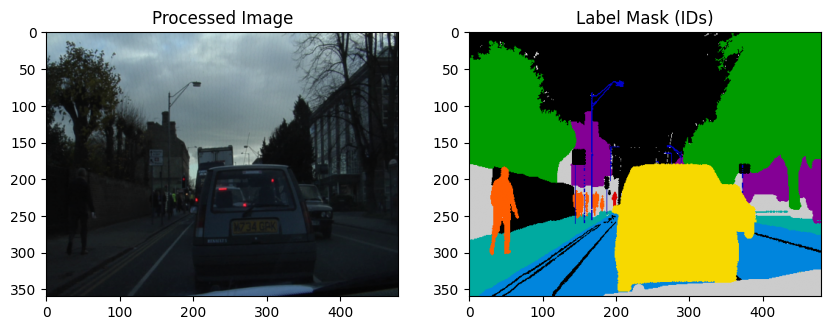

In [11]:
def visualize_check(dataset, index=0):
    img, mask = dataset[index]

    # Un-normalize image for viewing
    img_view = img.permute(1, 2, 0).numpy()
    img_view = img_view * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_view = np.clip(img_view, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_view)
    plt.title("Processed Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='nipy_spectral')
    plt.title("Label Mask (IDs)")
    plt.show()

visualize_check(train_ds)

Baseline

In [12]:
def get_miou(preds, labels, num_classes=12):
    preds = torch.argmax(preds, dim=1)
    ious = []
    for c in range(num_classes):
        intersection = ((preds == c) & (labels == c)).sum().item()
        union = ((preds == c) | (labels == c)).sum().item()
        if union == 0:
            ious.append(float('nan')) # Ignore classes not in the image
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)

In [ ]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 12
model = BiSeNetV2_Baseline(num_classes=num_classes).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# Training and Validation Loop
epochs = 15
history = {'train_loss': [], 'val_miou': []}

print(f"Training started on {device}...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    # Training Phase
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Validation Phase (Calculating mIoU)
    model.eval()
    val_miou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            val_miou += get_miou(preds, masks, num_classes)

    avg_loss = epoch_loss / len(train_loader)
    avg_miou = val_miou / len(val_loader)

    history['train_loss'].append(avg_loss)
    history['val_miou'].append(avg_miou)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - mIoU: {avg_miou:.4f}")

#  Save Baseline Model 
torch.save(model.state_dict(), '/content/drive/MyDrive/bisenet_v2_baseline.pth')
print("Baseline training complete. Model saved as bisenet_v2_baseline.pth")

Training started on cuda...
Epoch [1/15] - Loss: 1.3525 - mIoU: 0.1614
Epoch [2/15] - Loss: 1.1153 - mIoU: 0.1616
Epoch [3/15] - Loss: 1.0875 - mIoU: 0.1904
Epoch [4/15] - Loss: 1.0367 - mIoU: 0.1706
Epoch [5/15] - Loss: 1.0205 - mIoU: 0.1952
Epoch [6/15] - Loss: 0.9785 - mIoU: 0.1921
Epoch [7/15] - Loss: 0.9683 - mIoU: 0.1918
Epoch [8/15] - Loss: 0.9684 - mIoU: 0.2124
Epoch [9/15] - Loss: 0.9354 - mIoU: 0.2210
Epoch [10/15] - Loss: 0.9219 - mIoU: 0.2364
Epoch [11/15] - Loss: 0.8950 - mIoU: 0.2348
Epoch [12/15] - Loss: 0.8851 - mIoU: 0.2145
Epoch [13/15] - Loss: 0.8851 - mIoU: 0.2185
Epoch [14/15] - Loss: 0.8733 - mIoU: 0.2184
Epoch [15/15] - Loss: 0.8755 - mIoU: 0.2377
Baseline training complete. Model saved as bisenet_v2_baseline.pth


In [15]:
test_ds = CamVidDataset(
    os.path.join(DATA_PATH, 'test/images'),
    os.path.join(DATA_PATH, 'test/labels'),
    transform=transform
)


In [18]:
from models import BiSeNetV2_Baseline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_base = BiSeNetV2_Baseline(num_classes=12).to(device)
model_base.load_state_dict(
    torch.load('/content/drive/MyDrive/bisenet_v2_baseline.pth')
)
model_base.eval()


BiSeNetV2_Baseline(
  (detail): DetailBranch(
    (stage1): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (stage2): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (stage3): ConvBNReLU(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
  )
  (semantic): SemanticBranch(
    (stage1): ConvBNReLU(
      (block): Sequential(
        (0): Conv

In [ ]:
# Visualize the result
import random
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_baseline(model, dataset, device, num_samples=3):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(15, 5 * num_samples))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.argmax(model(image_tensor), dim=1).squeeze(0).cpu().numpy()

        # Un-normalize image
        img = image.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(mask, cmap="nipy_spectral")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred, cmap="nipy_spectral")
        plt.title("Baseline Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


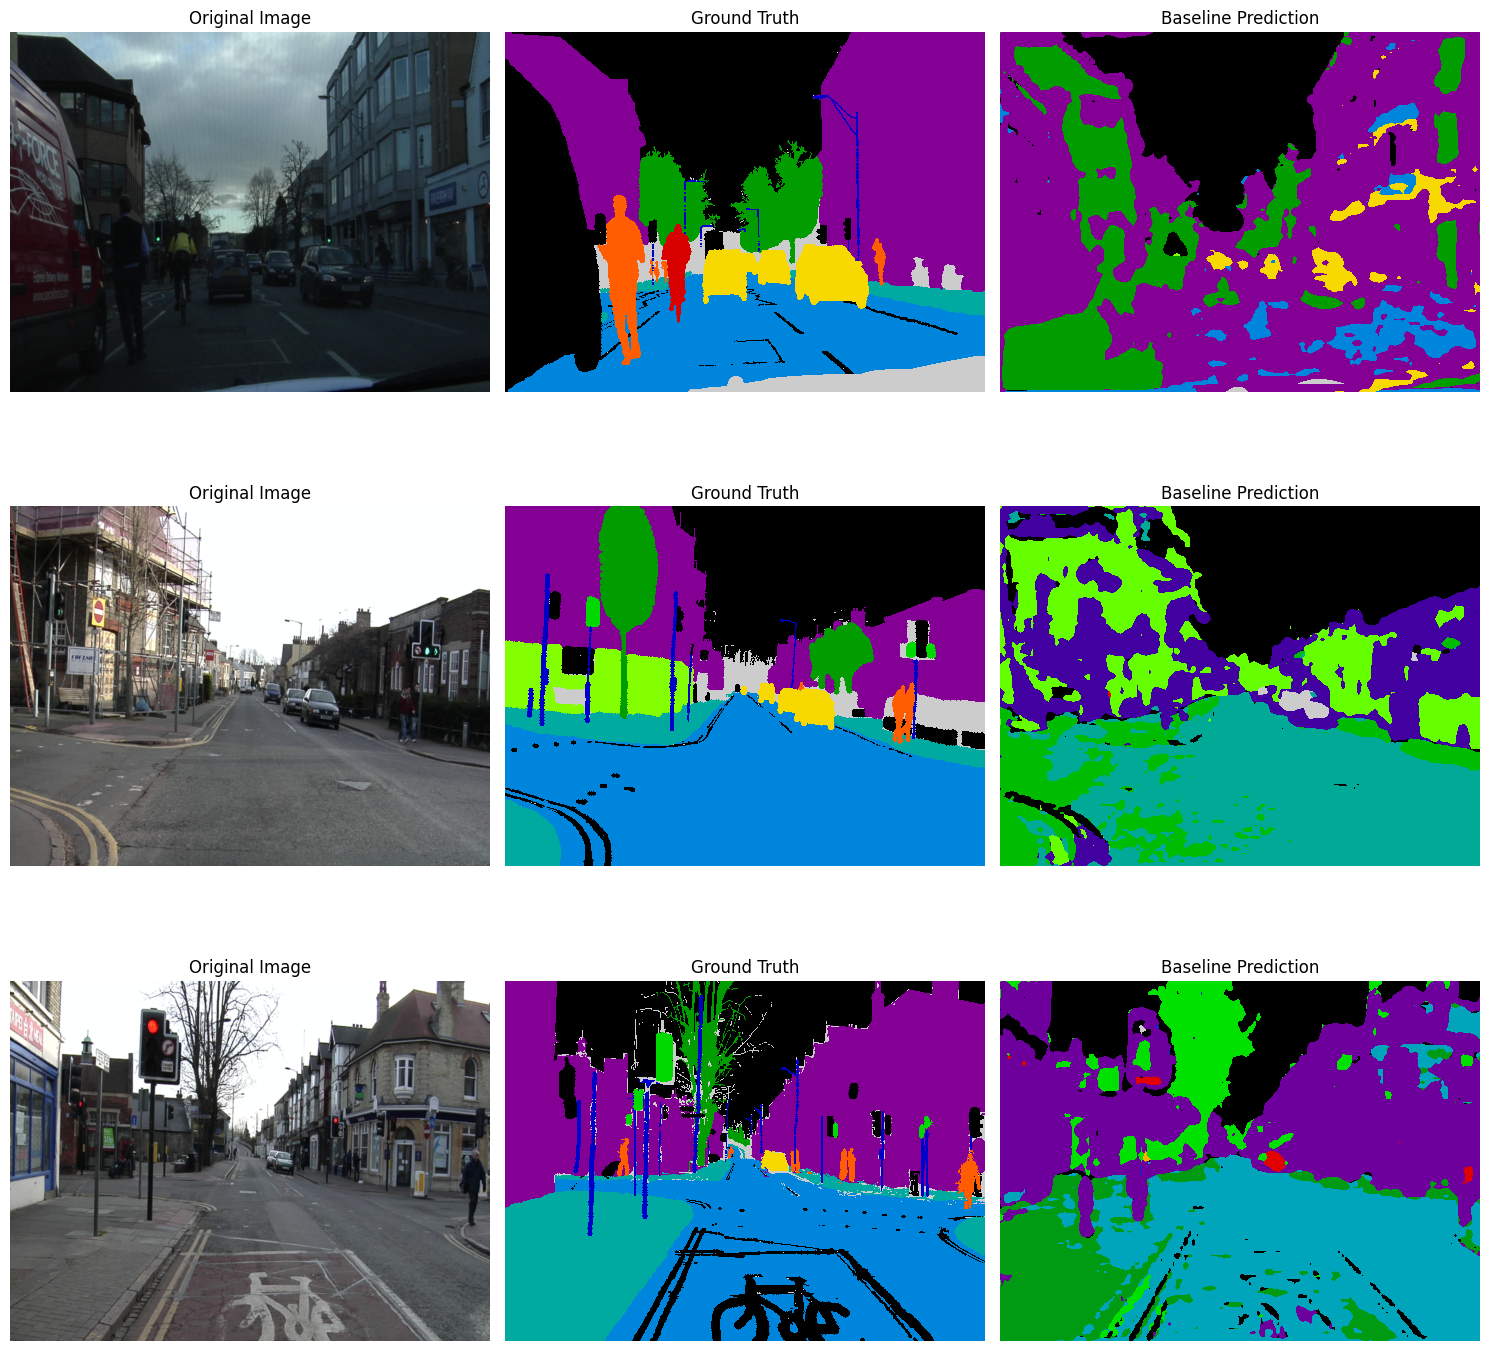

In [20]:
visualize_random_baseline(model_base, test_ds, device, num_samples=3)
